In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import keras

In [14]:
ANNO_DIR = "/Users/shreyasgotur/Downloads/deepfashion_anno/Category and Attribute Prediction Benchmark/Anno_fine"
IMG_DIR = "/Users/shreyasgotur/Downloads/img"

In [15]:
# for fine annotations
fine_lookup_df = pd.read_csv(
    os.path.join(ANNO_DIR, "list_attr_cloth.txt"),
    sep=r"\s+",
    skiprows=1,
    header=0
)
my_headers = list(fine_lookup_df['attribute_name'].unique())

attribute_to_string_dict = {1: 'pattern', 2: 'sleeve style', 3: 'dress type', 4: 'neckline', 5: 'material', 6:'fit'}
fine_lookup_df['attribute_type_str'] = fine_lookup_df['attribute_type'].apply(lambda x: attribute_to_string_dict[x])
fine_lookup_df.set_index('attribute_name', inplace=True)

fine_label_df = pd.read_csv(
    os.path.join(ANNO_DIR, "train_attr.txt"),
    sep=r"\s+",
    names=my_headers
)

fine_train_image_name_df = pd.read_csv(
    os.path.join(ANNO_DIR, "train.txt"),
    sep=r"\s+",
    names = ['img_name']
)
fine_category_train_df = pd.read_csv(
    os.path.join(ANNO_DIR, "train_cate.txt"),
    sep=r"\s+",
    names = ['category']
)

fine_category_lookup_df = pd.read_csv(os.path.join(ANNO_DIR, "list_category_cloth.txt"), sep=r"\s+", skiprows=1, header=0)
fine_category_lookup_df['key'] = fine_category_lookup_df.index+1

train_df_with_category = pd.concat([fine_train_image_name_df, fine_category_train_df], axis=1)
train_df_with_category = train_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
train_df_with_category['category_type_tf'] = train_df_with_category['category_type']-1

In [16]:
# validation set, same pattern as train
fine_val_image_name_df = pd.read_csv(
    os.path.join(ANNO_DIR, "val.txt"),
    sep=r"\s+",
    names = ['img_name']
)
fine_category_val_df = pd.read_csv(
    os.path.join(ANNO_DIR, "val_cate.txt"),
    sep=r"\s+",
    names = ['category']
)

val_df_with_category = pd.concat([fine_val_image_name_df, fine_category_val_df], axis=1)
val_df_with_category = val_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
val_df_with_category['category_type_tf'] = val_df_with_category['category_type']-1

category_dict = {1: 'upper body', 2: 'lower body', 3: 'full body'}

In [17]:
# define load image function
IMG_SIZE = (224, 224)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

In [18]:
# build train and val datasets
batch_size = 64

train_files = [os.path.join(IMG_DIR, os.path.relpath(f, "img")) for f in train_df_with_category['img_name'].to_list()]
train_category_type_labels = train_df_with_category['category_type_tf'].to_list()
unique_category_types = list(set(train_category_type_labels))
print(len(train_files))
print(unique_category_types)

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_category_type_labels))
    .shuffle(len(train_files))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_files = [os.path.join(IMG_DIR, os.path.relpath(f, "img")) for f in val_df_with_category['img_name'].to_list()]
val_category_type_labels = val_df_with_category['category_type_tf'].to_list()
print(len(val_files))

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_category_type_labels))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

14000
[0, 1, 2]
2000


(64, 224, 224, 3)
tf.Tensor(
[1 2 2 2 1 0 2 0 2 0 0 1 0 0 0 0 2 2 1 2 0 2 1 1 0 1 0 0 1 0 2 2 0 0 0 1 2
 0 2 2 2 2 0 0 1 0 2 2 1 2 0 0 0 2 0 1 1 1 2 0 0 0 0 2], shape=(64,), dtype=int32)


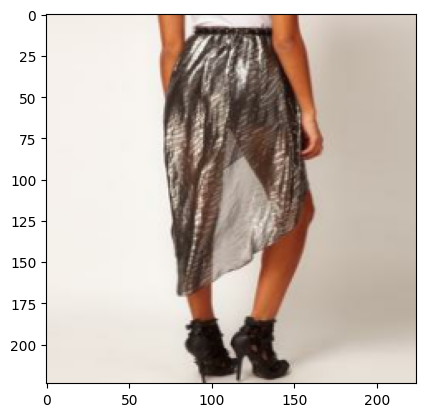

2026-07-31 19:35:58.243055: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
# quick check that the pipeline looks right
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels)
    plt.imshow(images[0].numpy())
    plt.show()

In [20]:
# baseline logistic regression model
NUM_CLASSES = 3

def build_multiclass_logreg(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES, lr=0.001):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_multiclass_logreg()

In [ ]:
# early stopping and learning rate schedule
es = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[es, reduce_lr]
)

Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4582 - loss: 19.5141 - val_accuracy: 0.5600 - val_loss: 4.7283 - learning_rate: 0.0010
Epoch 2/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5202 - loss: 7.0709 - val_accuracy: 0.5345 - val_loss: 3.6823 - learning_rate: 0.0010
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5414 - loss: 5.9496 - val_accuracy: 0.6650 - val_loss: 2.8883 - learning_rate: 0.0010
Epoch 4/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5785 - loss: 4.5333 - val_accuracy: 0.4630 - val_loss: 10.4704 - learning_rate: 0.0010
Epoch 5/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5456 - loss: 5.9024 - val_accuracy: 0.6400 - val_loss: 2.4422 - learning_rate: 0.0010
Epoch 6/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5341 - loss: 7.5326 - val_accuracy: 0.5865 - val_loss: 6.1946 - learning_rate: 0.0010
Epoch 7/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6618 - loss: 

In [22]:
model.evaluate(val_ds)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6807 - loss: 2.8260


[2.888270378112793, 0.6650000214576721]

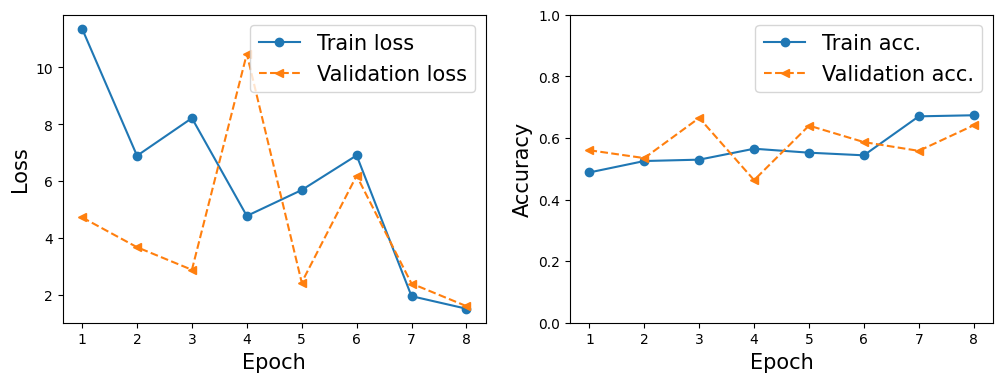

In [23]:
# plot loss and accuracy curves
hist = history.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['accuracy'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_accuracy'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
ax.set_ylim(0,1)
plt.show()

In [25]:
import os
print(os.getcwd())

/Users/shreyasgotur/Downloads


In [26]:
os.makedirs('./models', exist_ok=True)
model.save('./models/logreg_baseline.keras')

<h1>Load Best Model</h1>

In [27]:
model_loaded = tf.keras.models.load_model("./models/logreg_baseline.keras")

In [28]:
# test set, same pattern as train and val
fine_test_image_name_df = pd.read_csv(
    os.path.join(ANNO_DIR, "test.txt"),
    sep=r"\s+",
    names = ['img_name']
)
fine_category_test_df = pd.read_csv(
    os.path.join(ANNO_DIR, "test_cate.txt"),
    sep=r"\s+",
    names = ['category']
)

test_df_with_category = pd.concat([fine_test_image_name_df, fine_category_test_df], axis=1)
test_df_with_category = test_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
test_df_with_category['category_type_tf'] = test_df_with_category['category_type']-1

test_files = [os.path.join(IMG_DIR, os.path.relpath(f, "img")) for f in test_df_with_category['img_name'].to_list()]
print(len(test_files))
test_category_type_labels = test_df_with_category['category_type_tf'].to_list()

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_category_type_labels))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

4000


In [29]:
model_loaded.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6580 - loss: 2.8645


[2.8283774852752686, 0.6600000262260437]

In [30]:
# subgroup performance by category type
from sklearn.metrics import classification_report

category_mapping = {
    0: 'upper body',
    1: 'lower body',
    2: 'full body'
}

y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model_loaded.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

category_names = [category_mapping[k] for k in sorted(category_mapping.keys())]
print(classification_report(y_true, y_pred, target_names=category_names, digits=3))

              precision    recall  f1-score   support

  upper body      0.734     0.739     0.736      1873
  lower body      0.672     0.397     0.499       779
   full body      0.573     0.703     0.631      1348

    accuracy                          0.660      4000
   macro avg      0.659     0.613     0.622      4000
weighted avg      0.667     0.660     0.655      4000



2026-07-31 19:37:42.617549: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
